In [1]:
from evaluate_classifier import evaluate_classifier

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

In [4]:
dataset = pd.read_csv("../dataset/cmi_internet_cleaned.csv")

In [5]:
X = dataset.drop("sii", axis=1)
y = dataset["sii"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7839, 32)
Target shape: (7839,)


In [6]:
target_distribution = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "proportion": y.value_counts(normalize=True).sort_index()
})

target_distribution

,count,proportion
sii,,
0,5476,0.698558
1,1444,0.184207
2,846,0.107922
3,73,0.009312


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Train shape: (5487, 32)
Test shape: (2352, 32)

Train target distribution:
sii
0    0.698560
1    0.184254
2    0.107891
3    0.009295
Name: proportion, dtype: float64

Test target distribution:
sii
0    0.698554
1    0.184099
2    0.107993
3    0.009354
Name: proportion, dtype: float64


In [8]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

## Base SVM

In [9]:
svm_base = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=42
    ))
])

svm_base.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('clf', SVC(random_state=42))])

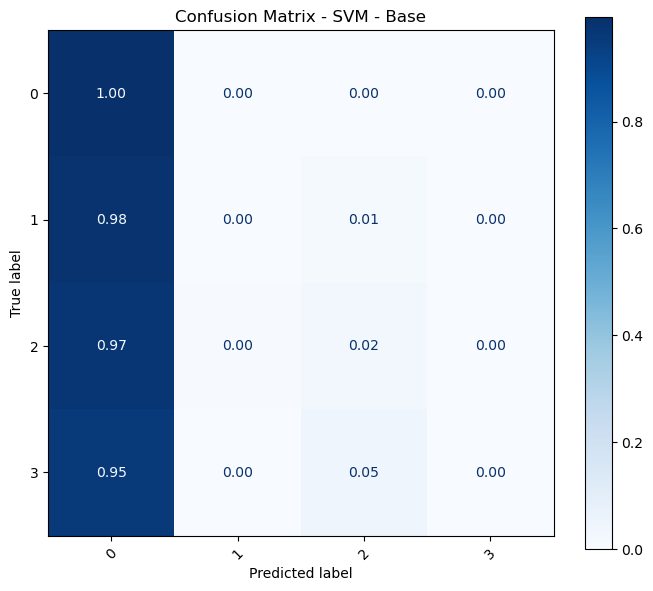


Classification report - SVM - Base


,precision,recall,f1-score,support
0,0.702274,0.996348,0.823855,1643.00000
1,0.200000,0.002309,0.004566,433.00000
2,0.375000,0.023622,0.044444,254.00000
3,0.000000,0.000000,0.000000,22.00000
accuracy,0.698980,0.698980,0.698980,0.69898
macro avg,0.319318,0.255570,0.218216,2352.00000
weighted avg,0.567894,0.698980,0.581148,2352.00000


In [10]:
results_svm_base, report_svm_base = evaluate_classifier(
    model=svm_base,
    X_test=X_test,
    y_test=y_test,
    model_name="SVM - Base",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False,
    normalize_cm="true"
)

In [11]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

linear_svm_c_results = []

for C in C_values:
    linear_svm = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(
            C=C,
            random_state=42,
            max_iter=20000
        ))
    ])
    
    scores = cross_validate(
        linear_svm,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "f1_macro": "f1_macro",
            "f1_weighted": "f1_weighted"
        },
        n_jobs=-1
    )
    
    linear_svm_c_results.append({
        "model": f"Linear SVM C={C}",
        "C": C,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1_macro": scores["test_f1_macro"].mean(),
        "f1_weighted": scores["test_f1_weighted"].mean()
    })

linear_svm_c_results_df = pd.DataFrame(linear_svm_c_results)

linear_svm_c_results_df.sort_values("f1_macro", ascending=False)

,model,C,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,Linear SVM C=0.001,0.001,0.696373,0.263373,0.236427,0.591224
1,Linear SVM C=0.01,0.010,0.696920,0.261960,0.233536,0.590029
2,Linear SVM C=0.1,0.100,0.696738,0.261895,0.233447,0.589917
3,Linear SVM C=1,1.000,0.696738,0.261895,0.233447,0.589917
4,Linear SVM C=10,10.000,0.696738,0.261895,0.233447,0.589917
5,Linear SVM C=100,100.000,0.696738,0.261895,0.233447,0.589917


In [13]:
linear_svm_balanced_c_results = []

for C in C_values:
    linear_svm_balanced = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(
            C=C,
            class_weight="balanced",
            random_state=42,
            max_iter=20000
        ))
    ])
    
    scores = cross_validate(
        linear_svm_balanced,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "f1_macro": "f1_macro",
            "f1_weighted": "f1_weighted"
        },
        n_jobs=-1
    )
    
    linear_svm_balanced_c_results.append({
        "model": f"Linear SVM Balanced C={C}",
        "C": C,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1_macro": scores["test_f1_macro"].mean(),
        "f1_weighted": scores["test_f1_weighted"].mean()
    })

linear_svm_balanced_c_results_df = pd.DataFrame(linear_svm_balanced_c_results)

linear_svm_balanced_c_results_df.sort_values("f1_macro", ascending=False)

,model,C,accuracy,balanced_accuracy,f1_macro,f1_weighted
1,Linear SVM Balanced C=0.01,0.010,0.644068,0.347225,0.314209,0.617154
3,Linear SVM Balanced C=1,1.000,0.642610,0.345459,0.312980,0.616228
4,Linear SVM Balanced C=10,10.000,0.642610,0.345459,0.312980,0.616228
5,Linear SVM Balanced C=100,100.000,0.642610,0.345459,0.312980,0.616228
2,Linear SVM Balanced C=0.1,0.100,0.642245,0.345146,0.312419,0.615773
0,Linear SVM Balanced C=0.001,0.001,0.643521,0.346655,0.311377,0.614414


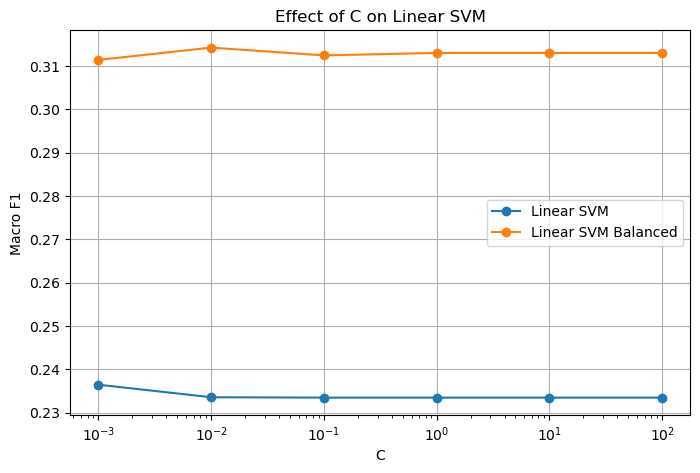

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    linear_svm_c_results_df["C"],
    linear_svm_c_results_df["f1_macro"],
    marker="o",
    label="Linear SVM"
)

plt.plot(
    linear_svm_balanced_c_results_df["C"],
    linear_svm_balanced_c_results_df["f1_macro"],
    marker="o",
    label="Linear SVM Balanced"
)

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Macro F1")
plt.title("Effect of C on Linear SVM")
plt.legend()
plt.grid(True)
plt.show()

## Tuned SVM without imbalance correction

In [15]:
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(random_state=42))
])

param_grid_svm = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.1, 1, 10]
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale"]
    }
]

grid_svm = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)

print("Best parameters:")
print(grid_svm.best_params_)

print("\nBest CV F1 macro:")
print(grid_svm.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   0.3s
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   0.3s
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   0.3s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   0.4s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   0.5s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   0.6s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   0.7s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   0.8s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   0.7s
[CV] END ........clf__C=1, clf__gamma=scale, clf__kernel=rbf; total time=   0.8s
[CV] END ........clf__C=1, clf__gamma=scale, clf__kernel=rbf; total time=   0.8s
[CV] END ........clf__C=1, clf__gamma=scale, clf_

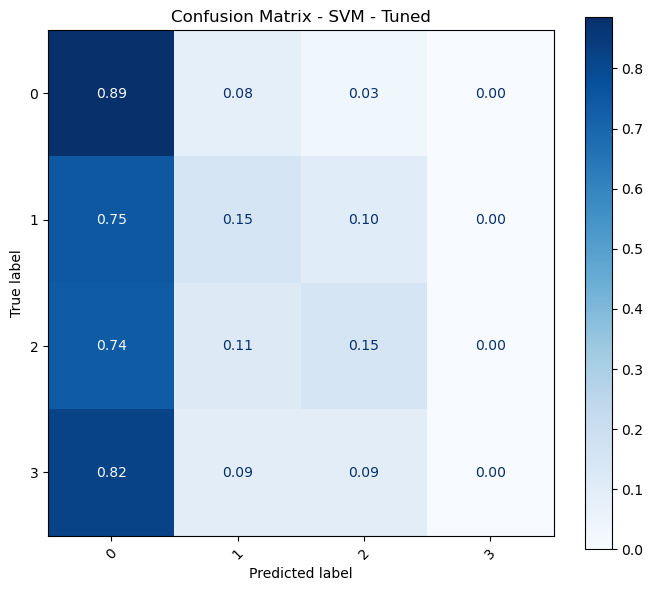


Classification report - SVM - Tuned


,precision,recall,f1-score,support
0,0.733132,0.886184,0.802425,1643.00000
1,0.278761,0.145497,0.191199,433.00000
2,0.273381,0.149606,0.193384,254.00000
3,0.000000,0.000000,0.000000,22.00000
accuracy,0.661990,0.661990,0.661990,0.66199
macro avg,0.321319,0.295322,0.296752,2352.00000
weighted avg,0.592975,0.661990,0.616621,2352.00000


In [16]:
best_svm = grid_svm.best_estimator_

results_svm_tuned, report_svm_tuned = evaluate_classifier(
    model=best_svm,
    X_test=X_test,
    y_test=y_test,
    model_name="SVM - Tuned",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False,
    normalize_cm="true"
)

## Tuned SVM with class weight balanced

In [17]:
svm_balanced_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(random_state=42))
])

param_grid_svm_balanced = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.1, 1, 10],
        "clf__class_weight": ["balanced"]
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale"],
        "clf__class_weight": ["balanced"]
    }
]

grid_svm_balanced = GridSearchCV(
    estimator=svm_balanced_pipe,
    param_grid=param_grid_svm_balanced,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_svm_balanced.fit(X_train, y_train)

print("Best parameters:")
print(grid_svm_balanced.best_params_)

print("\nBest CV F1 macro:")
print(grid_svm_balanced.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__kernel=linear; total time=   0.7s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__kernel=linear; total time=   0.7s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__kernel=linear; total time=   0.8s
[CV] END clf__C=1, clf__class_weight=balanced, clf__kernel=linear; total time=   1.2s
[CV] END clf__C=1, clf__class_weight=balanced, clf__kernel=linear; total time=   1.3s
[CV] END clf__C=1, clf__class_weight=balanced, clf__kernel=linear; total time=   1.4s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__gamma=scale, clf__kernel=rbf; total time=   1.0s
[CV] END clf__C=0.1, clf__class_weight=balanced, clf__gamma=scale, clf__kernel=rbf; total time=   1.1s
[CV] END clf__C=1, clf__class_weight=balanced, clf__gamma=scale, clf__kernel=rbf; total time=   1.0s
[CV] END clf__C=1, clf__class_weight=balanced, clf__gamma=scale, clf__kernel=rbf; total time=   1.0s
[CV] END c

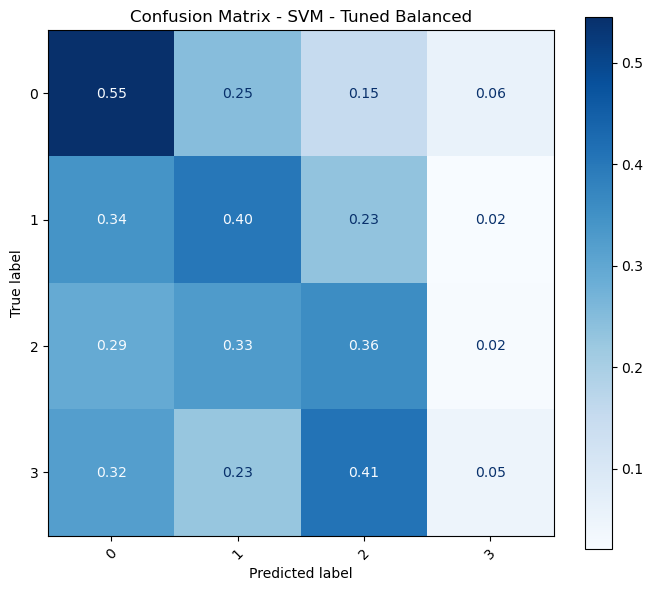


Classification report - SVM - Tuned Balanced


,precision,recall,f1-score,support
0,0.795737,0.545344,0.647165,1643.000000
1,0.260479,0.401848,0.316076,433.000000
2,0.202222,0.358268,0.258523,254.000000
3,0.009259,0.045455,0.015385,22.000000
accuracy,0.494048,0.494048,0.494048,0.494048
macro avg,0.316924,0.337728,0.309287,2352.000000
weighted avg,0.625745,0.494048,0.538332,2352.000000


In [18]:
best_svm_balanced = grid_svm_balanced.best_estimator_

results_svm_balanced_tuned, report_svm_balanced_tuned = evaluate_classifier(
    model=best_svm_balanced,
    X_test=X_test,
    y_test=y_test,
    model_name="SVM - Tuned Balanced",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False,
    normalize_cm="true"
)

## Tuned SVM with SMOTE

In [19]:
svm_smote_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", SVC(random_state=42))
])

param_grid_svm_smote = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.1, 1, 10],
        "smote__k_neighbors": [3, 5]
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale"],
        "smote__k_neighbors": [3, 5]
    }
]

grid_svm_smote = GridSearchCV(
    estimator=svm_smote_pipe,
    param_grid=param_grid_svm_smote,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_svm_smote.fit(X_train, y_train)

print("Best parameters:")
print(grid_svm_smote.best_params_)

print("\nBest CV F1 macro:")
print(grid_svm_smote.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=3; total time=   3.3s
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=5; total time=   3.4s
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=5; total time=   3.4s
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=5; total time=   3.5s
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=3; total time=   3.6s
[CV] END clf__C=0.1, clf__kernel=linear, smote__k_neighbors=3; total time=   3.7s
[CV] END .clf__C=1, clf__kernel=linear, smote__k_neighbors=3; total time=   7.6s
[CV] END .clf__C=1, clf__kernel=linear, smote__k_neighbors=3; total time=   7.8s
[CV] END .clf__C=1, clf__kernel=linear, smote__k_neighbors=3; total time=   7.9s
[CV] END .clf__C=1, clf__kernel=linear, smote__k_neighbors=5; total time=   7.9s
[CV] END .clf__C=1, clf__kernel=linear, smote__k_neighbors=5; total time=   8.1s
[CV] END .clf__C=1, clf__kernel=linear, sm

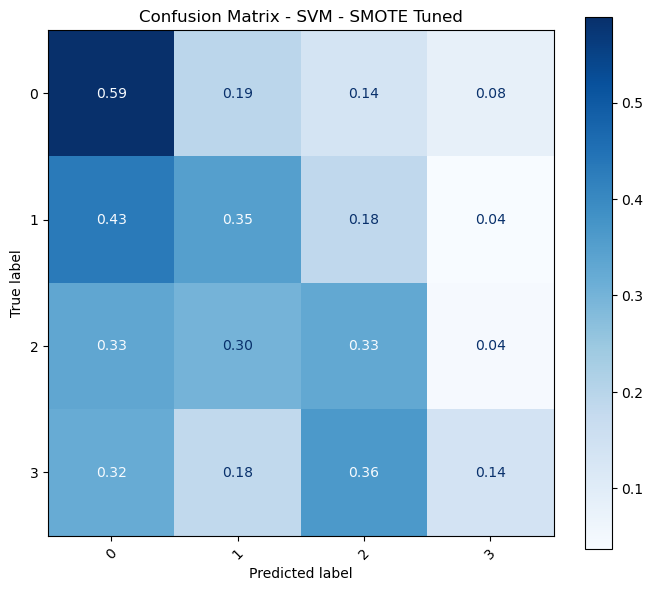


Classification report - SVM - SMOTE Tuned


,precision,recall,f1-score,support
0,0.777510,0.589166,0.670360,1643.00000
1,0.275046,0.348730,0.307536,433.00000
2,0.211196,0.326772,0.256569,254.00000
3,0.018182,0.136364,0.032086,22.00000
accuracy,0.512330,0.512330,0.512330,0.51233
macro avg,0.320483,0.350258,0.316638,2352.00000
weighted avg,0.616746,0.512330,0.552908,2352.00000


In [20]:
best_svm_smote = grid_svm_smote.best_estimator_

results_svm_smote_tuned, report_svm_smote_tuned = evaluate_classifier(
    model=best_svm_smote,
    X_test=X_test,
    y_test=y_test,
    model_name="SVM - SMOTE Tuned",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False,
    normalize_cm="true"
)

## Tuned SVM with SMOTE-Tomek

In [21]:
svm_smote_tomek_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote_tomek", SMOTETomek(random_state=42)),
    ("clf", SVC(random_state=42))
])

param_grid_svm_smote_tomek = [
    {
        "clf__kernel": ["linear"],
        "clf__C": [0.1, 1, 10]
    },
    {
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale"]
    }
]

grid_svm_smote_tomek = GridSearchCV(
    estimator=svm_smote_tomek_pipe,
    param_grid=param_grid_svm_smote_tomek,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_svm_smote_tomek.fit(X_train, y_train)

print("Best parameters:")
print(grid_svm_smote_tomek.best_params_)

print("\nBest CV F1 macro:")
print(grid_svm_smote_tomek.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   3.9s
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   4.2s
[CV] END .....................clf__C=0.1, clf__kernel=linear; total time=   4.2s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   8.2s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   8.5s
[CV] END .......................clf__C=1, clf__kernel=linear; total time=   8.5s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   5.4s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf__kernel=rbf; total time=   5.4s
[CV] END ........clf__C=1, clf__gamma=scale, clf__kernel=rbf; total time=   4.2s
[CV] END ........clf__C=1, clf__gamma=scale, clf__kernel=rbf; total time=   4.4s
[CV] END .......clf__C=10, clf__gamma=scale, clf__kernel=rbf; total time=   3.6s
[CV] END ......clf__C=0.1, clf__gamma=scale, clf_

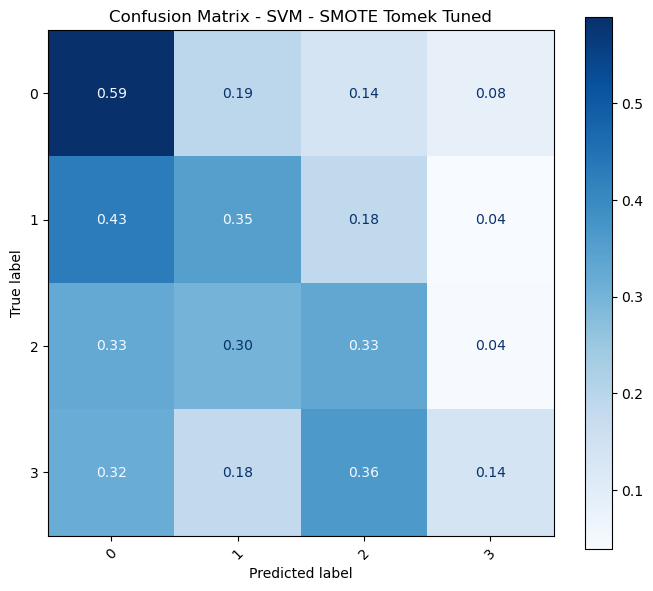


Classification report - SVM - SMOTE Tomek Tuned


,precision,recall,f1-score,support
0,0.778761,0.589166,0.670825,1643.000000
1,0.275547,0.348730,0.307849,433.000000
2,0.213198,0.330709,0.259259,254.000000
3,0.017964,0.136364,0.031746,22.000000
accuracy,0.512755,0.512755,0.512755,0.512755
macro avg,0.321368,0.351242,0.317420,2352.000000
weighted avg,0.617927,0.512755,0.553577,2352.000000


In [22]:
best_svm_smote_tomek = grid_svm_smote_tomek.best_estimator_

results_svm_smote_tomek_tuned, report_svm_smote_tomek_tuned = evaluate_classifier(
    model=best_svm_smote_tomek,
    X_test=X_test,
    y_test=y_test,
    model_name="SVM - SMOTE Tomek Tuned",
    labels=np.sort(y.unique()),
    average="weighted",
    plot_confusion=True,
    plot_roc=False,
    plot_pr=False,
    normalize_cm="true"
)

## Final comparison

In [23]:
svm_results_table = pd.DataFrame([
    results_svm_base,
    results_svm_tuned,
    results_svm_balanced_tuned,
    results_svm_smote_tuned,
    results_svm_smote_tomek_tuned
])

svm_results_table = svm_results_table.sort_values("f1_macro", ascending=False)

svm_results_table

,model,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,roc_auc_ovr_weighted,roc_auc_ovr_macro
4,SVM - SMOTE Tomek Tuned,0.512755,0.351242,0.617927,0.512755,0.553577,0.321368,0.351242,0.317420,0.619934,0.659876
3,SVM - SMOTE Tuned,0.512330,0.350258,0.616746,0.512330,0.552908,0.320483,0.350258,0.316638,0.619753,0.659738
2,SVM - Tuned Balanced,0.494048,0.337728,0.625745,0.494048,0.538332,0.316924,0.337728,0.309287,0.655064,0.667268
1,SVM - Tuned,0.661990,0.295322,0.592975,0.661990,0.616621,0.321319,0.295322,0.296752,0.635091,0.625755
0,SVM - Base,0.698980,0.255570,0.567894,0.698980,0.581148,0.319318,0.255570,0.218216,0.630940,0.624121


In [24]:
def extract_per_class_f1(report_df, model_name):
    class_labels = [str(label) for label in np.sort(y.unique())]
    
    available_labels = [label for label in class_labels if label in report_df.index]
    
    return pd.DataFrame({
        "class": available_labels,
        model_name: report_df.loc[available_labels, "f1-score"].values
    })


per_class_f1_svm = extract_per_class_f1(report_svm_base, "SVM Base")

for report, name in [
    (report_svm_tuned, "SVM Tuned"),
    (report_svm_balanced_tuned, "SVM Balanced"),
    (report_svm_smote_tuned, "SVM SMOTE"),
    (report_svm_smote_tomek_tuned, "SVM SMOTE Tomek")
]:
    temp = extract_per_class_f1(report, name)
    per_class_f1_svm = per_class_f1_svm.merge(temp, on="class", how="outer")

per_class_f1_svm

,class,SVM Base,SVM Tuned,SVM Balanced,SVM SMOTE,SVM SMOTE Tomek
0,0,0.823855,0.802425,0.647165,0.670360,0.670825
1,1,0.004566,0.191199,0.316076,0.307536,0.307849
2,2,0.044444,0.193384,0.258523,0.256569,0.259259
3,3,0.000000,0.000000,0.015385,0.032086,0.031746
